# Loan Approval — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv('archive/loan_approval_dataset.csv')

# strip whitespace from column names and drop id
df.columns = df.columns.str.strip()
df.drop(columns=['loan_id'], errors='ignore', inplace=True)

# standardise categorical values
cat_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
df[cat_cols] = df[cat_cols].apply(lambda col: col.astype(str).str.strip().str.lower())

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print('Shape:', df.shape)
print('Categorical:', cat_cols)
print('Numerical:  ', num_cols)
df.head(2)

Shape: (4269, 12)
Categorical: ['education', 'self_employed', 'loan_status']
Numerical:   ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,graduate,no,9600000,29900000,12,778,2400000,17600000,22700000,8000000,approved
1,0,not graduate,yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,rejected


In [3]:
print('Missing values:')
print(df.isnull().sum())
print('\nData types:')
df.info()

Missing values:
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   str  
 2   self_employed             4269 non-null   str  
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_v

## 2. Target Distribution

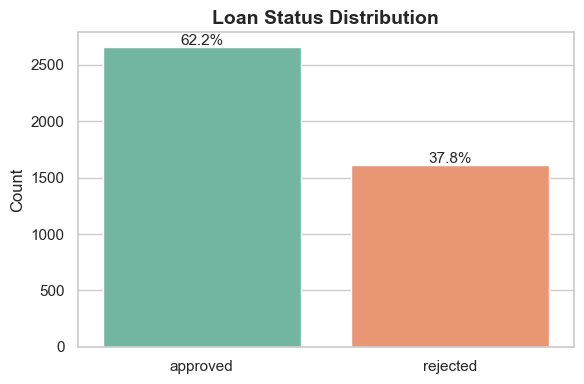

loan_status
approved    2656
rejected    1613
Name: count, dtype: int64


In [4]:
counts = df['loan_status'].value_counts()
pct = df['loan_status'].value_counts(normalize=True) * 100

sns.set_theme(style='whitegrid', palette='Set2')
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', palette='Set2', ax=ax)
for p, (label, percent) in zip(ax.patches, pct.items()):
    ax.annotate(f'{percent:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 20),
                ha='center', fontsize=11)
ax.set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(counts)

## 3. Categorical Bivariate Analysis

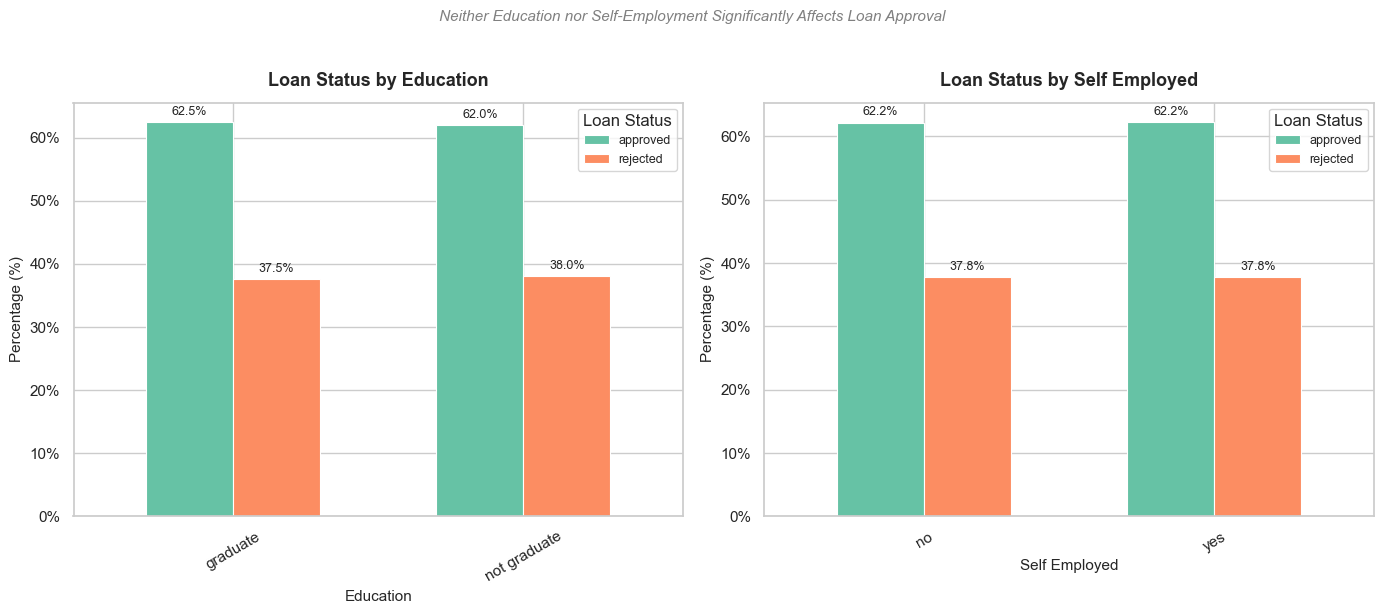

In [5]:
feature_cat_cols = [c for c in cat_cols if c != 'loan_status']

def plot_loan_status_by_cat(df, cols):
    sns.set_theme(style='whitegrid', palette='Set2')
    fig, axes = plt.subplots(1, len(cols), figsize=(7 * len(cols), 6))
    if len(cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
        ct.plot(kind='bar', ax=ax, rot=30, edgecolor='white', linewidth=0.8, width=0.6)
        ax.set_title(f'Loan Status by {col.replace("_", " ").title()}',
                     fontsize=13, fontweight='bold', pad=12)
        ax.set_ylabel('Percentage (%)', fontsize=11)
        ax.set_xlabel(col.replace('_', ' ').title(), fontsize=11)
        ax.legend(title='Loan Status', fontsize=9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)
    plt.suptitle('Neither Education nor Self-Employment Significantly Affects Loan Approval',
                 fontsize=11, fontstyle='italic', color='gray', y=1.02)
    plt.tight_layout()
    plt.show()

plot_loan_status_by_cat(df, feature_cat_cols)

**Observation:** Approval rate is ~62% regardless of education or self-employment status — neither feature is a meaningful standalone predictor.

## 4. Numerical Bivariate Analysis

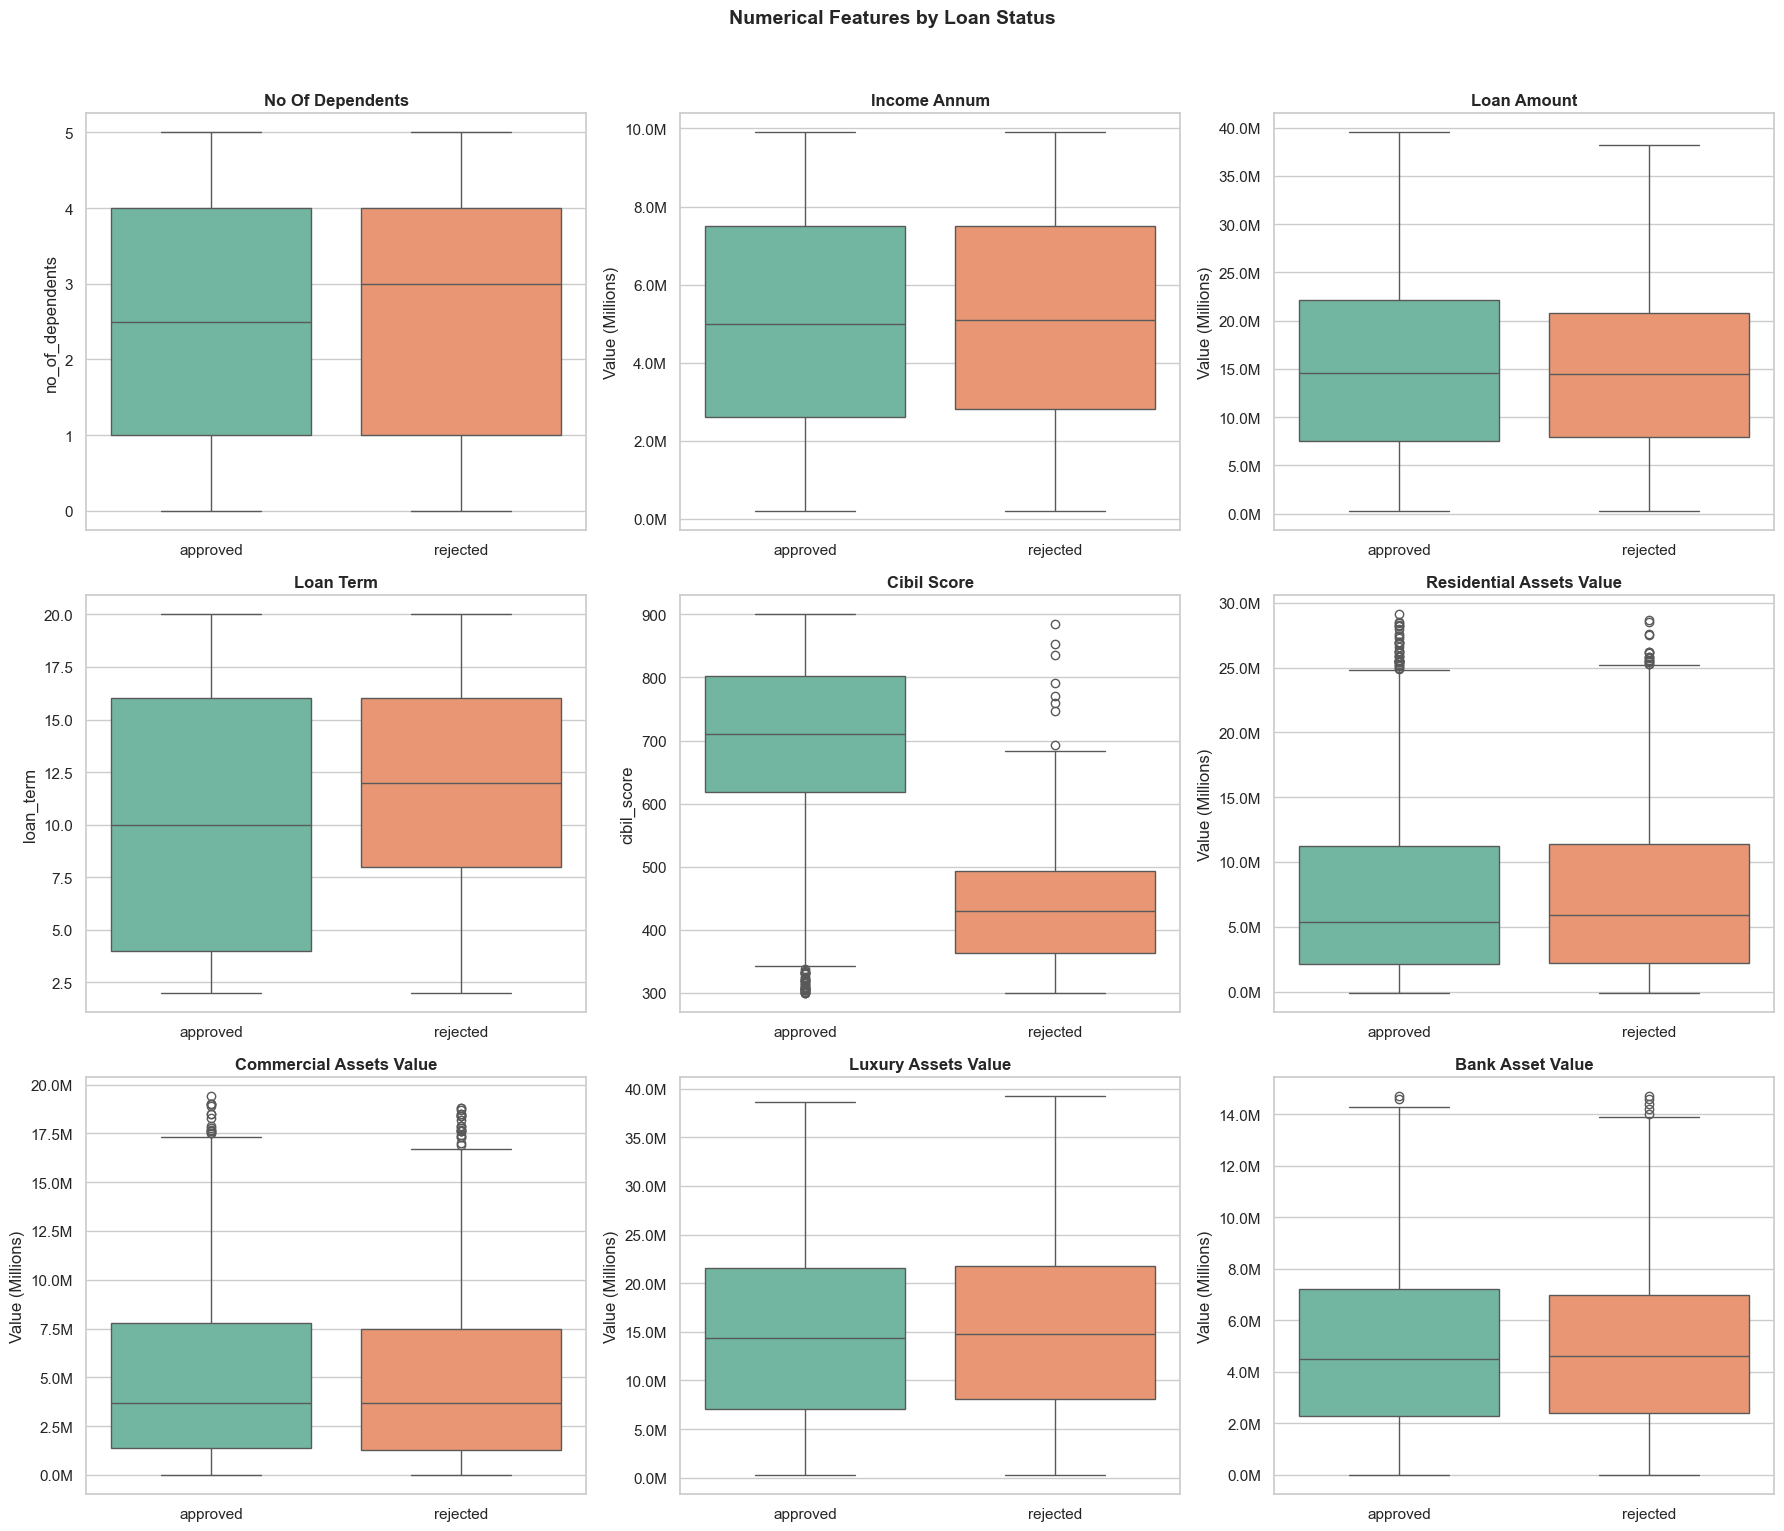

In [6]:
def format_yaxis(ax, col_max):
    if col_max >= 1e6:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        ax.set_ylabel('Value (Millions)')
    elif col_max >= 1e3:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.1f}K'))
        ax.set_ylabel('Value (Thousands)')

def plot_num_vs_loan_status(df, num_cols):
    sns.set_theme(style='whitegrid')
    ncols = 3
    nrows = (len(num_cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(num_cols):
        sns.boxplot(data=df, x='loan_status', y=col, palette='Set2', ax=axes[i])
        axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        format_yaxis(axes[i], df[col].max())
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Numerical Features by Loan Status', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_num_vs_loan_status(df, num_cols)

In [7]:
# CIBIL score is the standout — confirm with descriptive stats
df.groupby('loan_status')['cibil_score'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
approved,2656.0,703.461973,125.249016,300.0,618.0,711.0,803.0,900.0
rejected,1613.0,429.468072,78.401752,300.0,364.0,429.0,493.0,885.0


**Observation:** CIBIL score shows clear separation — approved median ~711 vs rejected ~429. All other features overlap almost completely between groups.

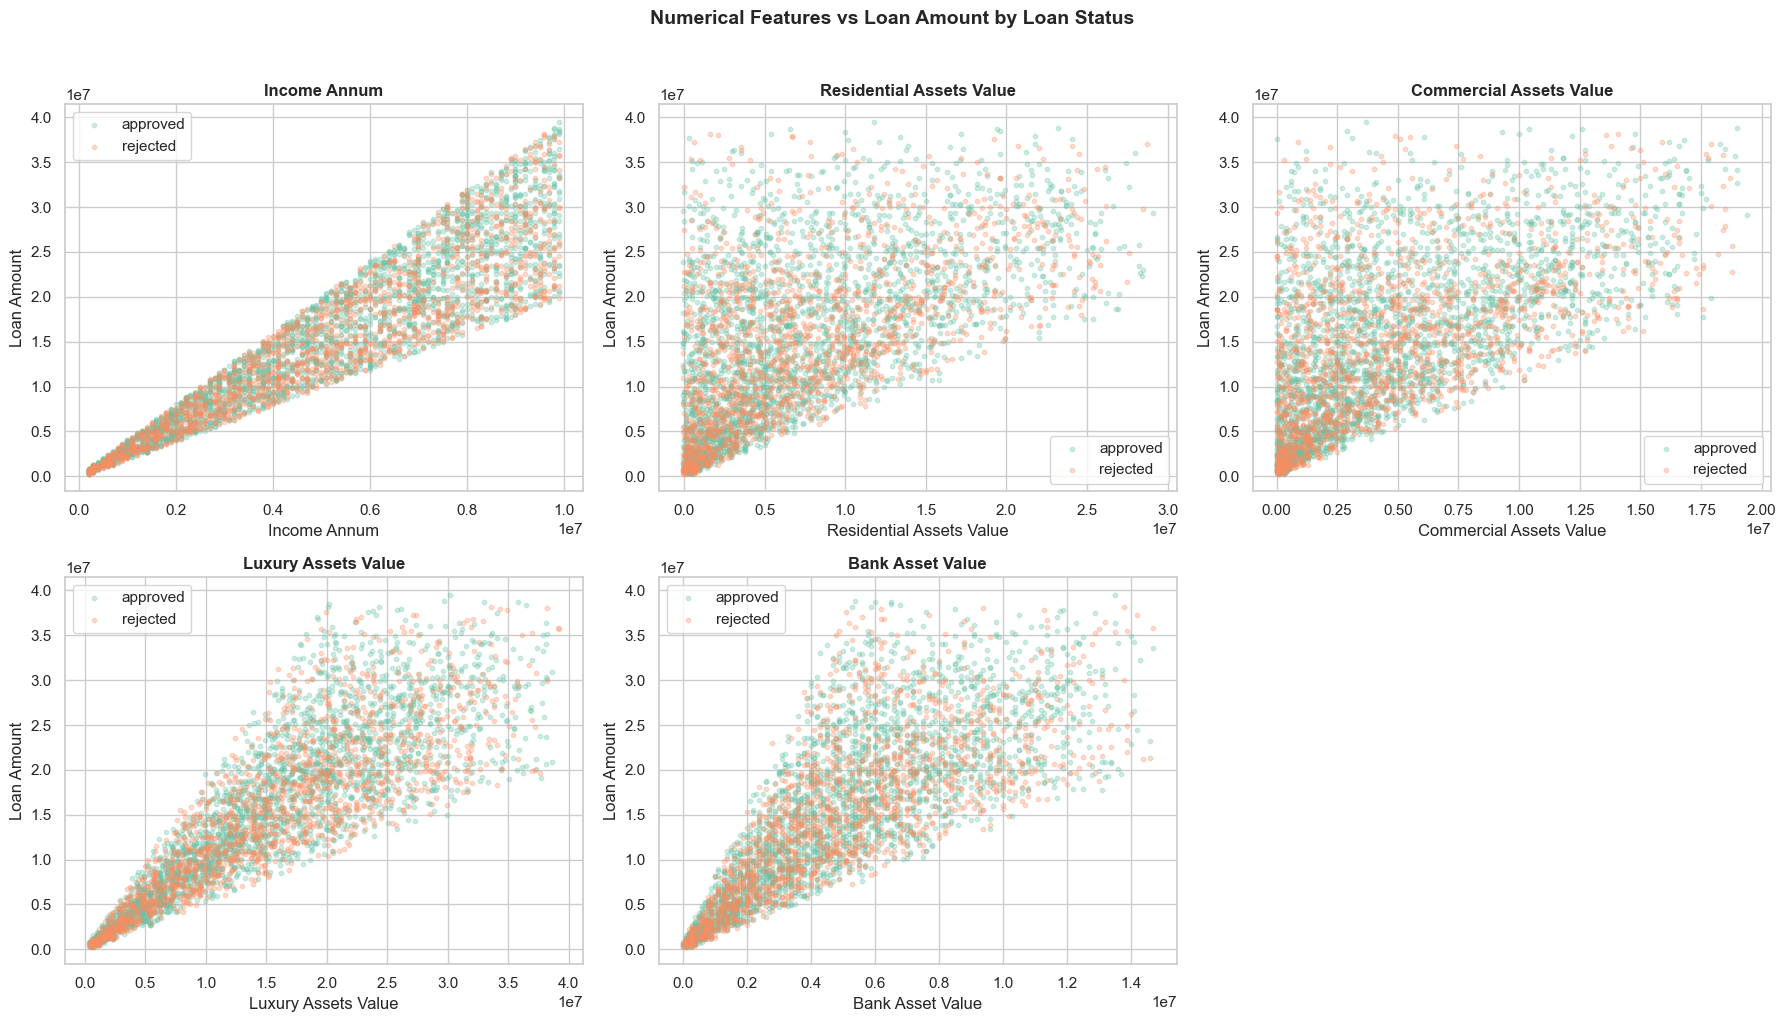

In [16]:
exclude = ['loan_amount', 'no_of_dependents', 'loan_term', 'cibil_score']
plot_cols = [c for c in num_cols if c not in exclude]

ncols = 3
nrows = (len(plot_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    for status, grp in df.groupby('loan_status'):
        axes[i].scatter(grp[col], grp['loan_amount'], alpha=0.3, label=status, s=10)
    axes[i].set_xlabel(col.replace('_', ' ').title())
    axes[i].set_ylabel('Loan Amount')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Loan Amount by Loan Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. CIBIL Score — Binned Approval Rate

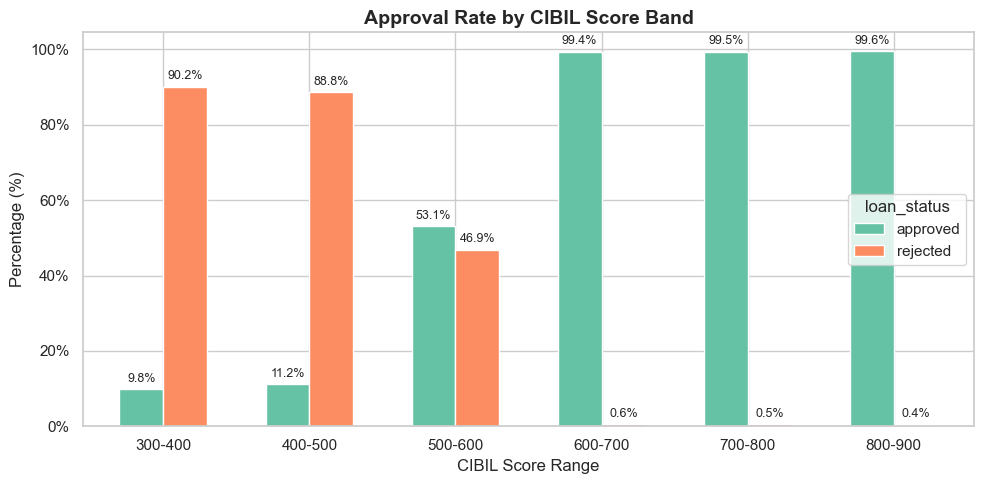

In [8]:
bins = [300, 400, 500, 600, 700, 800, 900]
labels = ['300-400', '400-500', '500-600', '600-700', '700-800', '800-900']
df['cibil_bin'] = pd.cut(df['cibil_score'], bins=bins, labels=labels)

ct = pd.crosstab(df['cibil_bin'], df['loan_status'], normalize='index') * 100

sns.set_theme(style='whitegrid', palette='Set2')
ax = ct.plot(kind='bar', figsize=(10, 5), rot=0, edgecolor='white', width=0.6)
ax.set_title('Approval Rate by CIBIL Score Band', fontsize=14, fontweight='bold')
ax.set_xlabel('CIBIL Score Range')
ax.set_ylabel('Percentage (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)
plt.tight_layout()
plt.show()

## 6. Engineered Features

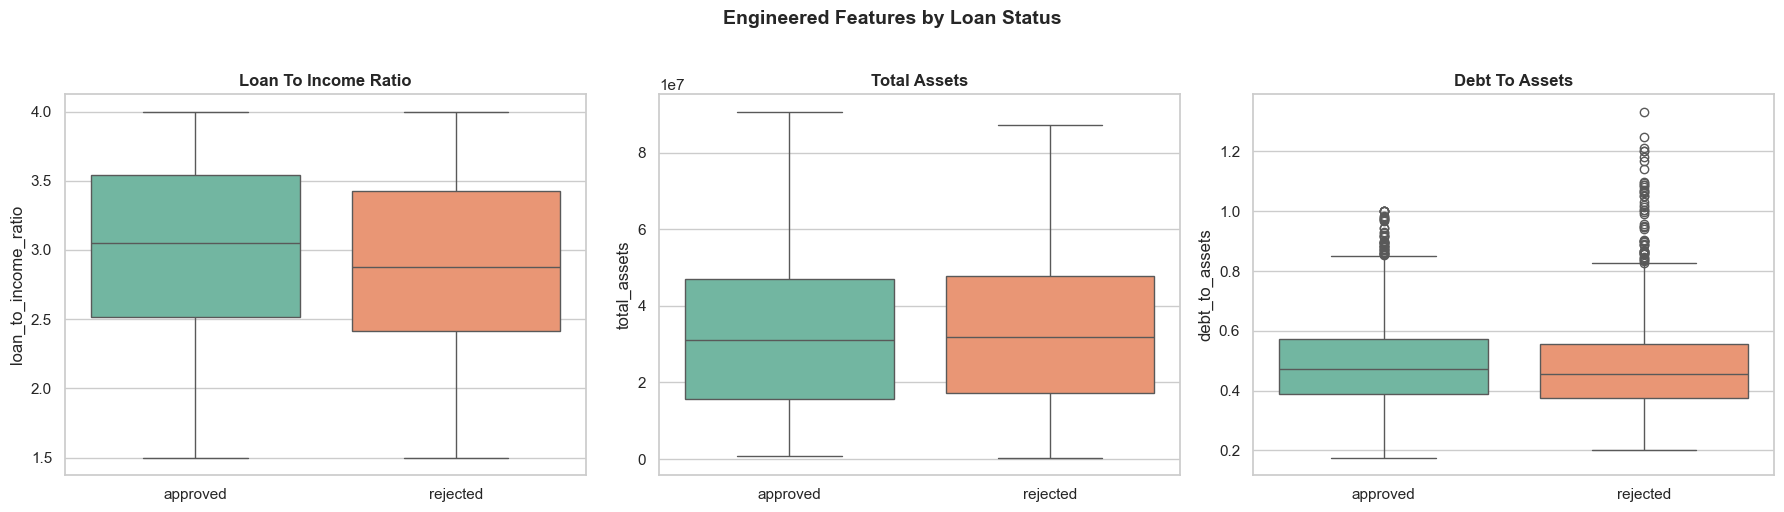

In [9]:
df['loan_to_income_ratio'] = df['loan_amount'] / df['income_annum']
df['total_assets'] = (df['residential_assets_value'] + df['commercial_assets_value'] +
                      df['luxury_assets_value'] + df['bank_asset_value'])
df['debt_to_assets'] = df['loan_amount'] / df['total_assets'].replace(0, np.nan)

engineered = ['loan_to_income_ratio', 'total_assets', 'debt_to_assets']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, engineered):
    sns.boxplot(data=df, x='loan_status', y=col, palette='Set2', ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Engineered Features by Loan Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observations — Engineered Features

| Feature | Hypothesis | Formula | Outcome |
|---|---|---|---|
| `loan_to_income_ratio` | Higher ratio (borrowing too much relative to income) → more likely rejected | `loan_amount / income_annum` | No effect — approved and rejected show identical distributions (~3x median) |
| `total_assets` | More total wealth → better collateral → more likely approved | `residential + commercial + luxury + bank assets` | No effect — distributions overlap completely |
| `debt_to_assets` | Higher leverage (loan large relative to assets) → riskier → more likely rejected | `loan_amount / total_assets` | No effect — medians and IQRs nearly identical across both groups |

**Takeaway:** None of the engineered features separate approved from rejected loans. Combined with the raw feature analysis, this strongly suggests the bank's decision is almost entirely driven by CIBIL score, not by income, assets, or borrowing ratios.

## 7. Correlation Heatmap

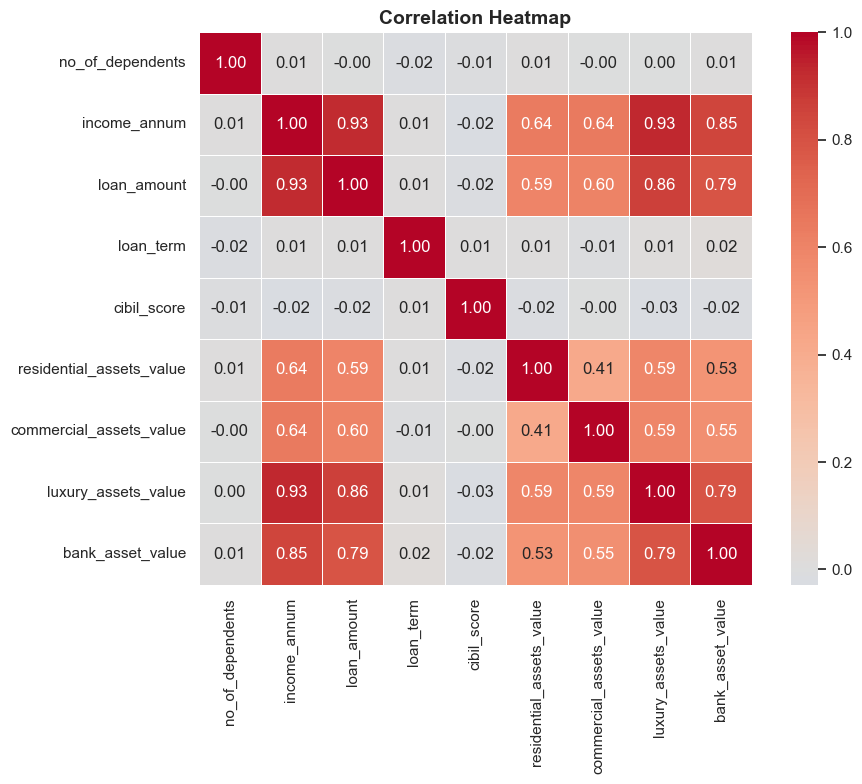

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
1. `income_annum` ↔ `loan_amount`: 0.93 — high earners borrow more
2. `income_annum` ↔ `luxury_assets_value`: 0.93 — wealthier people own more luxury assets
3. `income_annum` ↔ `bank_asset_value`: 0.85
4. `loan_amount` ↔ `luxury_assets_value`: 0.86
5. `cibil_score` is uncorrelated with everything (~0.00) — it is an independent signal

In [11]:
df.head(3)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,cibil_bin,loan_to_income_ratio,total_assets,debt_to_assets
0,2,graduate,no,9600000,29900000,12,778,2400000,17600000,22700000,8000000,approved,700-800,3.114583,50700000,0.589744
1,0,not graduate,yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,rejected,400-500,2.975610,17000000,0.717647
2,3,graduate,no,9100000,29700000,20,506,7100000,4500000,33300000,12800000,rejected,500-600,3.263736,57700000,0.514731
